# Linear Models: Linear Regression, Ridge, and LASSO

This lab explores linear regression models using the **Diabetes dataset** from `scikit-learn`.

Three models are implemented and compared:
- **Ordinary Linear Regression (OLS)**: standard least-squares baseline without regularization.
- **Ridge Regression ($L_2$ Regularization)**: shrinks coefficients toward zero to handle collinearity and reduce variance.
- **LASSO Regression ($L_1$ Regularization)**: enforces sparsity by driving less informative coefficients to zero, performing automatic feature selection.

The following tasks are performed:
- Load and inspect the dataset, including summary statistics and distribution plots.
- Partition data into training (70%) and testing (30%) subsets.
- Fit and evaluate the three baseline models using Mean Squared Error (MSE).
- Compare feature selection capabilities by counting non-zero weights.
- Visualize and analyze the learned coefficients across models.
- Experiment with a range of regularization strengths ($\alpha \in [10^{-3}, 10^2]$) to analyze trade-offs in prediction error and model complexity.

# 1. Exploratory Data Analysis & Preprocessing

The Diabetes dataset comprises 442 patient records with 10 baseline physiological predictors (`age`, `sex`, `bmi`, `bp`, and six blood serum measurements `s1` to `s6`). The target variable is a quantitative measure of diabetes progression one year after baseline.

> **Note on Feature Scaling**: In `scikit-learn`, each of the 10 features in `load_diabetes` has already been mean-centered and scaled such that the sum of squares across each column equals 1 (standard deviation $\approx 1/\sqrt{n}$). Regularization penalties ($L_1$, $L_2$) are sensitive to feature scales; because the predictors share an identical scale, no additional standard scaling is required.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_diabetes

# Load the Diabetes dataset
diabetes = load_diabetes()

# Convert features and target to pandas structures
X = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

y = pd.Series(
    diabetes.target,
    name="target"
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nFirst 5 rows:")
print(X.head())

X shape: (442, 10)
y shape: (442,)

Features:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

First 5 rows:
        age       sex       bmi  ...        s4        s5        s6
0  0.038076  0.050680  0.061696  ... -0.002592  0.019907 -0.017646
1 -0.001882 -0.044642 -0.051474  ... -0.039493 -0.068332 -0.092204
2  0.085299  0.050680  0.044451  ... -0.002592  0.002861 -0.025930
3 -0.089063 -0.044642 -0.011595  ...  0.034309  0.022688 -0.009362
4  0.005383 -0.044642 -0.036385  ... -0.002592 -0.031988 -0.046641

[5 rows x 10 columns]


## 1.1 Data Inspection and Missing Values

In [2]:
print("=" * 50)
print("DATA TYPES")
print("=" * 50)
print(X.dtypes)

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(X.isnull().sum())

print("\n" + "=" * 50)
print("FEATURE STATISTICS")
print("=" * 50)
print(X.describe().round(4))

print("\n" + "=" * 50)
print("TARGET STATISTICS")
print("=" * 50)
print(y.describe().round(4))

DATA TYPES
age    float64
sex    float64
bmi    float64
bp     float64
s1     float64
s2     float64
s3     float64
s4     float64
s5     float64
s6     float64
dtype: object

MISSING VALUES
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

FEATURE STATISTICS
            age       sex       bmi  ...        s4        s5        s6
count  442.0000  442.0000  442.0000  ...  442.0000  442.0000  442.0000
mean    -0.0000    0.0000   -0.0000  ...   -0.0000    0.0000    0.0000
std      0.0476    0.0476    0.0476  ...    0.0476    0.0476    0.0476
min     -0.1072   -0.0446   -0.0903  ...   -0.0764   -0.1261   -0.1378
25%     -0.0373   -0.0446   -0.0342  ...   -0.0395   -0.0332   -0.0332
50%      0.0054   -0.0446   -0.0073  ...   -0.0026   -0.0019   -0.0011
75%      0.0381    0.0507    0.0312  ...    0.0343    0.0324    0.0279
max      0.1107    0.0507    0.1706  ...    0.1852    0.1336    0.1356

[8 rows x 10 columns]

TARGET STATISTICS
count

## 1.2 Feature and Target Distributions

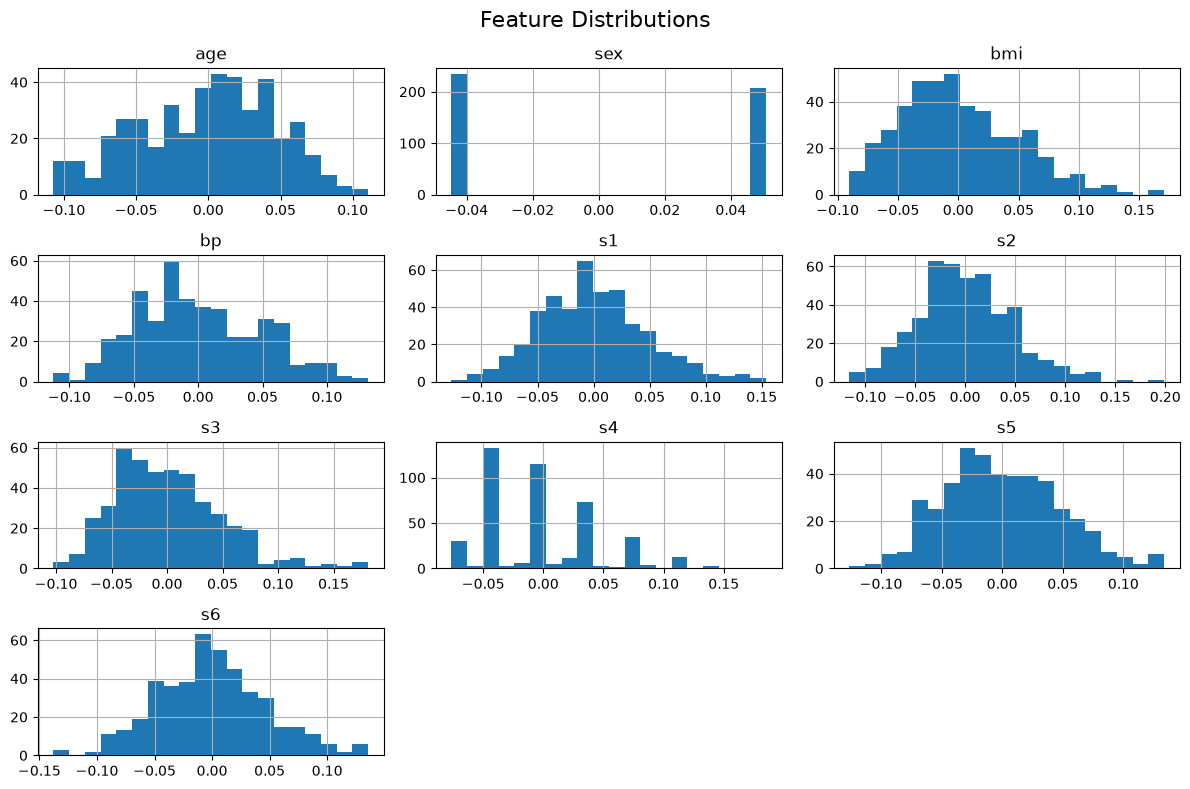

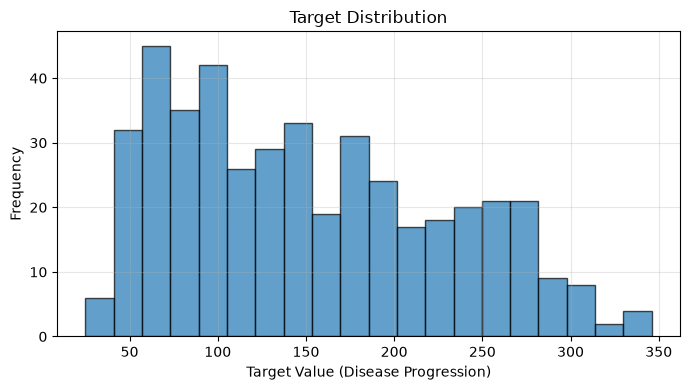

In [3]:
# Plot feature distributions
X.hist(figsize=(12, 8), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

# Plot target distribution
plt.figure(figsize=(7, 4))
plt.hist(y, bins=20, edgecolor="black", alpha=0.7)
plt.xlabel("Target Value (Disease Progression)")
plt.ylabel("Frequency")
plt.title("Target Distribution")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Train / Test Split

The dataset is partitioned into a **70% training set** and a **30% test set** with `random_state=42` to guarantee reproducible splits.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (309, 10)
y_train: (309,)

Testing set:
X_test: (133, 10)
y_test: (133,)


# 3. Ordinary Linear Regression (OLS)

Ordinary Linear Regression models the relationship between the predictors $\mathbf{x} = [x_1, \dots, x_p]^T$ and continuous target $y$ via a linear combination:

$$
\hat{y} = \beta_0 + \sum_{j=1}^{p} \beta_j x_j
$$

where:
- $\hat{y}$: predicted target value.
- $\beta_0$: intercept (bias).
- $\beta_j$: coefficient (weight) of feature $j$.
- $x_j$: value of feature $j$.
- $p$: number of features ($p = 10$).

The parameters are estimated by minimizing the **Mean Squared Error (MSE)** on the training data without regularization:

$$
\min_{\beta_0, \boldsymbol{\beta}} \frac{1}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2 = \min_{\beta_0, \boldsymbol{\beta}} \frac{1}{n}\sum_{i=1}^{n}\left(y_i - \left(\beta_0 + \sum_{j=1}^{p} \beta_j x_{ij}\right)\right)^2
$$

where $n$ is the number of training samples ($n = 309$).

In [5]:
from sklearn.linear_model import LinearRegression

# Instantiate and fit Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression trained successfully.")
print("\nIntercept (beta_0):", linear_model.intercept_)

print("\nCoefficients (beta_1 to beta_p):")
for feat, coef in zip(X.columns, linear_model.coef_):
    print(f"  {feat:6s}: {coef:10.4f}")

Linear Regression trained successfully.

Intercept (beta_0): 151.00821291456543

Coefficients (beta_1 to beta_p):
  age   :    29.2540
  sex   :  -261.7065
  bmi   :   546.2997
  bp    :   388.3983
  s1    :  -901.9597
  s2    :   506.7632
  s3    :   121.1544
  s4    :   288.0353
  s5    :   659.2690
  s6    :    41.3767


### Evaluation on Test Set

Model generalization performance is evaluated using the Mean Squared Error (MSE) on the unseen test set:

$$
\text{MSE} = \frac{1}{n_{\text{test}}}\sum_{i=1}^{n_{\text{test}}}(y_i - \hat{y}_i)^2
$$

In [6]:
from sklearn.metrics import mean_squared_error

# Predict on test set
y_pred_linear = linear_model.predict(X_test)

# Compute MSE
mse_linear = mean_squared_error(y_test, y_pred_linear)
print(f"Linear Regression Test MSE: {mse_linear:.4f}")

Linear Regression Test MSE: 2821.7510


# 4. Ridge Regression ($L_2$ Regularization)

Ridge Regression introduces an **$L_2$ penalty** to the loss function, penalizing large coefficient values:

$$
\min_{\beta_0, \boldsymbol{\beta}} \left[ \frac{1}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2 + \alpha\sum_{j=1}^{p}\beta_j^2 \right]
$$

where:
- $\alpha \ge 0$: regularization strength hyperparameter.
- $\sum_{j=1}^{p}\beta_j^2 = \|\boldsymbol{\beta}\|_2^2$: $L_2$ norm penalty (the intercept $\beta_0$ is unpenalized).

> **Properties of Ridge**:
> - Ridge shrinks coefficients smoothly toward zero as $\alpha$ increases, curbing variance and mitigating multicollinearity.
> - Because the $L_2$ constraint boundary is spherical/circular, solutions rarely land exactly on coordinate axes; hence, Ridge does not set coefficients strictly to zero and retains all features.

In this experiment:

$$
\alpha = 0.1
$$

In [7]:
from sklearn.linear_model import Ridge

# Instantiate and train Ridge model
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train, y_train)

# Predict on test set
y_pred_ridge = ridge_model.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print("Ridge Regression trained successfully.")
print("\nIntercept (beta_0):", ridge_model.intercept_)
print(f"\nRidge Regression Test MSE: {mse_ridge:.4f}")

Ridge Regression trained successfully.

Intercept (beta_0): 151.0525340484514

Ridge Regression Test MSE: 2805.4013


# 5. LASSO Regression ($L_1$ Regularization)

LASSO (Least Absolute Shrinkage and Selection Operator) applies an **$L_1$ penalty** proportional to the sum of absolute values of the coefficients:

$$
\min_{\beta_0, \boldsymbol{\beta}} \left[ \frac{1}{2n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2 + \alpha\sum_{j=1}^{p}|\beta_j| \right]
$$

where:
- $\alpha \ge 0$: regularization strength hyperparameter.
- $\sum_{j=1}^{p}|\beta_j| = \|\boldsymbol{\beta}\|_1$: $L_1$ norm penalty (the intercept $\beta_0$ is unpenalized).

> **Properties of LASSO**:
> - The geometric contour of the $L_1$ ball has sharp corners on the coordinate axes.
> - As the elliptical loss contours expand, they frequently touch the $L_1$ ball at these corners, setting certain coefficients **exactly to zero**.
> - LASSO thus conducts automatic **feature selection**, yielding sparse and more interpretable models.

In this experiment:

$$
\alpha = 0.1
$$

In [8]:
from sklearn.linear_model import Lasso

# Instantiate and train LASSO model
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train, y_train)

# Predict on test set
y_pred_lasso = lasso_model.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

print("LASSO Regression trained successfully.")
print("\nIntercept (beta_0):", lasso_model.intercept_)
print(f"\nLASSO Regression Test MSE: {mse_lasso:.4f}")

LASSO Regression trained successfully.

Intercept (beta_0): 151.07032226207454

LASSO Regression Test MSE: 2775.1651


# 6. Comparison of Baseline Models and Feature Selection

A feature $j$ is considered selected by the model if its learned coefficient is non-zero:

$$
N_{\text{selected}} = \sum_{j=1}^{p}\mathbb{I}(\beta_j \neq 0)
$$

where $\mathbb{I}(\cdot)$ is the indicator function.

Linear Regression and Ridge typically retain non-zero coefficients across all features, whereas LASSO can shrink subset coefficients strictly to zero.

In [9]:
# Count non-zero coefficients
n_features_linear = int(np.sum(linear_model.coef_ != 0))
n_features_ridge = int(np.sum(ridge_model.coef_ != 0))
n_features_lasso = int(np.sum(lasso_model.coef_ != 0))

# Baseline comparison table
baseline_summary = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge (alpha=0.1)", "LASSO (alpha=0.1)"],
    "Test MSE": [mse_linear, mse_ridge, mse_lasso],
    "Selected Features": [n_features_linear, n_features_ridge, n_features_lasso]
})

print("=" * 60)
print("BASELINE MODEL COMPARISON (alpha = 0.1)")
print("=" * 60)
print(baseline_summary.to_string(index=False))

# Identify zeroed vs active features in LASSO
zero_features = X.columns[lasso_model.coef_ == 0].tolist()
active_features = X.columns[lasso_model.coef_ != 0].tolist()

print(f"\nLASSO (alpha=0.1) eliminated {len(zero_features)} feature(s): {zero_features}")
print(f"LASSO (alpha=0.1) retained {len(active_features)} feature(s): {active_features}")

BASELINE MODEL COMPARISON (alpha = 0.1)
            Model    Test MSE  Selected Features
Linear Regression 2821.750981                 10
Ridge (alpha=0.1) 2805.401298                 10
LASSO (alpha=0.1) 2775.165076                  7

LASSO (alpha=0.1) eliminated 3 feature(s): ['age', 's2', 's4']
LASSO (alpha=0.1) retained 7 feature(s): ['sex', 'bmi', 'bp', 's1', 's3', 's5', 's6']


# 7. Visualization and Comparison of Model Weights

Analyzing model weights across features illustrates how regularization alters the magnitude and distribution of learned parameters:
- **Linear Regression (OLS)** learns unconstrained weights, which can fluctuate wildly when features exhibit correlation.
- **Ridge Regression** dampens coefficient magnitudes via $L_2$ shrinkage.
- **LASSO Regression** drives selected coefficients to zero via $L_1$ shrinkage, highlighting the most predictive subset.

COEFFICIENT VALUES ACROSS MODELS
Feature  Linear Regression  Ridge (alpha=0.1)  LASSO (alpha=0.1)
    age              29.25              39.66               0.00
    sex            -261.71            -213.85            -173.27
    bmi             546.30             505.91             558.94
     bp             388.40             341.71             339.35
     s1            -901.96            -108.81             -58.72
     s2             506.76             -70.58              -0.00
     s3             121.15            -211.91            -274.11
     s4             288.04             160.19               0.00
     s5             659.27             332.77             372.84
     s6              41.38              77.68              25.59


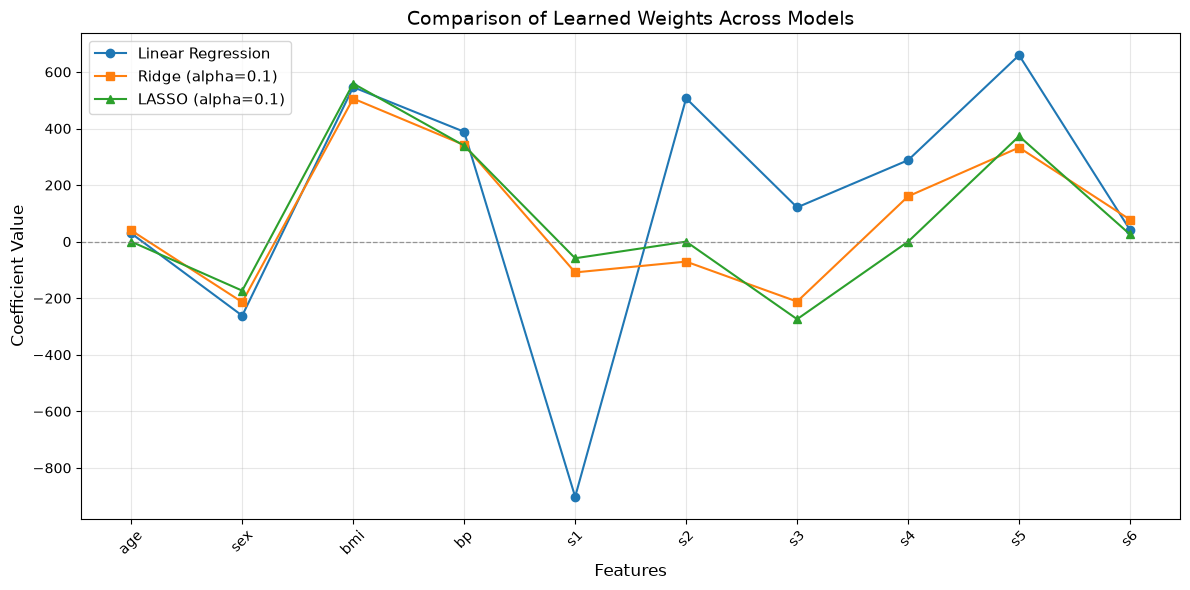

In [10]:
# Compare model coefficients numerically
coef_comparison = pd.DataFrame({
    "Feature": X.columns,
    "Linear Regression": linear_model.coef_,
    "Ridge (alpha=0.1)": ridge_model.coef_,
    "LASSO (alpha=0.1)": lasso_model.coef_
})

print("=" * 60)
print("COEFFICIENT VALUES ACROSS MODELS")
print("=" * 60)
print(coef_comparison.round(2).to_string(index=False))

# Plot weight comparison
features = X.columns

plt.figure(figsize=(12, 6))
plt.plot(features, linear_model.coef_, marker='o', linewidth=1.5, label='Linear Regression')
plt.plot(features, ridge_model.coef_, marker='s', linewidth=1.5, label='Ridge (alpha=0.1)')
plt.plot(features, lasso_model.coef_, marker='^', linewidth=1.5, label='LASSO (alpha=0.1)')

plt.axhline(0, color='gray', linestyle='--', linewidth=0.9, alpha=0.8)

plt.xlabel("Features", fontsize=12)
plt.ylabel("Coefficient Value", fontsize=12)
plt.title("Comparison of Learned Weights Across Models", fontsize=14)
plt.xticks(rotation=45)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

1. **Multicollinearity in OLS**: In unregularized Linear Regression, blood serum features `s1` and `s2` display large opposing coefficients ($-901.96$ vs $+506.76$), a hallmark of multicollinearity where collinear predictors compensate for each other with inflated variances.
2. **Shrinkage in Ridge**: Ridge with $\alpha = 0.1$ effectively curbs this instability; the weight for `s1` drops sharply from $-901.96$ to $-108.81$, and `s2` drops to $-70.58$, reducing variance while preserving all 10 features.
3. **Sparsity in LASSO**: LASSO completely zeroes out `age`, `s2`, and `s4`, while achieving the lowest Test MSE ($2775.17$). The most influential positive predictor of disease progression across all models is `bmi`, followed by `s5` and `bp`.

# 8. Experiment with Different Regularization Strengths ($\alpha$)

The hyperparameter $\alpha$ governs the bias-variance trade-off:
- When $\alpha \to 0$, both Ridge and LASSO behave similarly to Ordinary Linear Regression (low bias, higher variance).
- For moderate values of $\alpha$ ($\alpha \approx 0.1$), regularization stabilizes weight estimation and minimizes test error.
- As $\alpha$ increases to large values ($\alpha \ge 10$), strong regularization forces coefficients toward zero, diminishing model capacity and resulting in underfitting (high bias).

We evaluate a logarithmic grid of $\alpha \in [10^{-3}, 10^{-2}, 10^{-1}, 10^0, 10^1, 10^2]$.

In [11]:
from sklearn.linear_model import Ridge, Lasso

alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_mse = []
lasso_mse = []
ridge_features = []
lasso_features = []

for alpha in alphas:
    # Ridge
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_pred_ridge = ridge.predict(X_test)
    ridge_mse.append(mean_squared_error(y_test, y_pred_ridge))
    ridge_features.append(int(np.sum(ridge.coef_ != 0)))

    # LASSO
    lasso = Lasso(alpha=alpha, random_state=42)
    lasso.fit(X_train, y_train)
    y_pred_lasso = lasso.predict(X_test)
    lasso_mse.append(mean_squared_error(y_test, y_pred_lasso))
    lasso_features.append(int(np.sum(lasso.coef_ != 0)))

# Aggregate results table
results = pd.DataFrame({
    "Alpha": alphas,
    "Ridge Test MSE": np.round(ridge_mse, 3),
    "Ridge Non-zero Features": ridge_features,
    "LASSO Test MSE": np.round(lasso_mse, 3),
    "LASSO Non-zero Features": lasso_features
})

print("=" * 65)
print("REGULARIZATION STRENGTH EXPERIMENT RESULTS")
print("=" * 65)
print(results.to_string(index=False))

REGULARIZATION STRENGTH EXPERIMENT RESULTS
  Alpha  Ridge Test MSE  Ridge Non-zero Features  LASSO Test MSE  LASSO Non-zero Features
  0.001        2820.614                       10        2820.402                       10
  0.010        2819.688                       10        2814.061                       10
  0.100        2805.401                       10        2775.165                        7
  1.000        3112.966                       10        3444.671                        3
 10.000        4580.108                       10        5432.886                        0
100.000        5318.577                       10        5432.886                        0


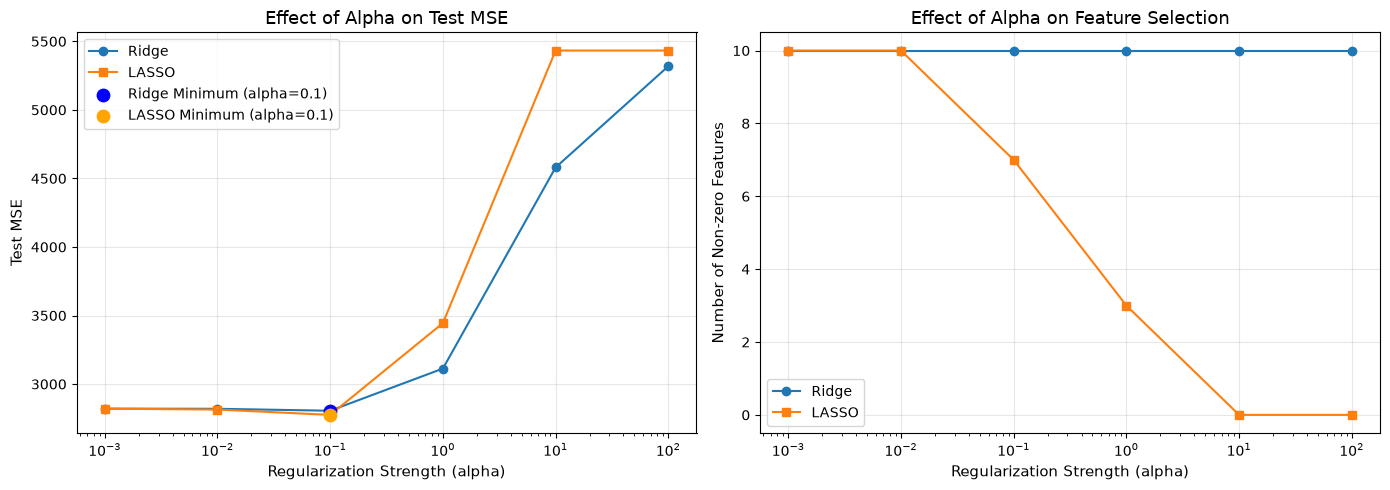

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Test MSE vs Alpha
axes[0].plot(alphas, ridge_mse, marker='o', linewidth=1.5, label='Ridge')
axes[0].plot(alphas, lasso_mse, marker='s', linewidth=1.5, label='LASSO')
axes[0].scatter([0.1], [mse_ridge], color='blue', s=80, zorder=5, label='Ridge Minimum (alpha=0.1)')
axes[0].scatter([0.1], [mse_lasso], color='orange', s=80, zorder=5, label='LASSO Minimum (alpha=0.1)')
axes[0].set_xscale('log')
axes[0].set_xlabel('Regularization Strength (alpha)', fontsize=11)
axes[0].set_ylabel('Test MSE', fontsize=11)
axes[0].set_title('Effect of Alpha on Test MSE', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Subplot 2: Number of Non-Zero Features vs Alpha
axes[1].plot(alphas, ridge_features, marker='o', linewidth=1.5, label='Ridge')
axes[1].plot(alphas, lasso_features, marker='s', linewidth=1.5, label='LASSO')
axes[1].set_xscale('log')
axes[1].set_xlabel('Regularization Strength (alpha)', fontsize=11)
axes[1].set_ylabel('Number of Non-zero Features', fontsize=11)
axes[1].set_title('Effect of Alpha on Feature Selection', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Analysis of Regularization Effects

The experiment illustrates the direct impact of regularization parameter $\alpha$ on generalization error and model sparsity:

1. **Prediction Performance**:
   - For weak regularization ($\alpha \in [0.001, 0.01]$), both models maintain test MSE values near Ordinary Linear Regression ($\approx 2820$).
   - At $\alpha = 0.1$, optimal regularization is attained for both Ridge ($2805.40$) and LASSO ($2775.17$).
   - For strong regularization ($\alpha \ge 1.0$), coefficient shrinkage becomes overly restrictive, elevating test error. At $\alpha \ge 10$, severe underfitting occurs ($\text{Test MSE} > 4500$).

2. **Feature Retention & Sparsity**:
   - **Ridge**: Retains all $10$ features regardless of $\alpha$. While weights shrink toward zero asymptotically, they are never zeroed out.
   - **LASSO**: Induces systematic feature pruning as $\alpha$ increases:
     - $\alpha = 0.001$ to $0.01$: $10$ features.
     - $\alpha = 0.1$: $7$ features (`age`, `s2`, `s4` removed).
     - $\alpha = 1.0$: $3$ features (`bmi`, `bp`, `s5` retained).
     - $\alpha \ge 10$: $0$ features (the model predicts solely the mean response via intercept $\beta_0$).

### Conclusion

- **Generalization Advantage**: Regularization provides measurable improvements over unregularized Ordinary Linear Regression. LASSO at $\alpha = 0.1$ achieved the lowest overall test error ($\text{MSE} = 2775.17$ vs $2821.75$ for OLS).
- **Interpretability and Sparsity**: LASSO successfully reduced model complexity by eliminating three redundant features without sacrificing predictive accuracy, creating a more compact and interpretable model.
- **Shrinkage Characteristics**: Ridge effectively mitigates collinearity among features by scaling weights proportionally, while LASSO selects sparse subsets by exploiting $L_1$ geometry.
- **Sensitivity to Alpha**: Performance is heavily dependent on $\alpha$; moderate penalization yields optimal bias-variance balance, whereas extreme penalization leads to underfitting.